# 03 · Trayectorias y perfiles: cómo se mueven los pacientes antes de la sepsis

**Fase CRISP-DM: Comprensión de los datos (cierre) → Preparación de los datos.**

En el notebook 01 (Sección 9) ya vimos el hallazgo central: las trayectorias medias de `HR`,
`Temp`, `Resp` y `MAP` alrededor del inicio de sepsis se mueven, pero de forma **modesta, no
dramática**. Este notebook no repite ese gráfico — lo rodea con otras formas de mirar el mismo
fenómeno, varias de ellas pensadas específicamente para "jugar con las horas": distribución
según tiempo de estancia, trayectorias individuales (no solo el promedio), perfiles
multivariantes y líneas de tiempo clínicas. Cada una es una pregunta distinta hecha
sobre los mismos datos, y cada una trae su propia evidencia — algunas confirman lo ya visto,
otras lo matizan o lo contradicen, y lo mostramos tal como sale.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
from pandas.plotting import parallel_coordinates
from sklearn.preprocessing import MinMaxScaler

sys.path.append(str(Path.cwd().parent / "src"))
import io_datos
import viz
from config import cargar_config

cfg = cargar_config()
df = io_datos.leer_cohorte(cfg)
viz.aplicar_estilo()
pd.set_option("display.max_columns", 50)

onset = df.loc[df.SepsisLabel == 1].groupby("pid", observed=True)["ICULOS"].min()
df["horas_hasta_sepsis"] = df["ICULOS"] - df["pid"].map(onset.reindex(df["pid"].cat.categories))
df["_septico_paciente"] = df.groupby("pid", observed=True)["SepsisLabel"].transform("max")

paciente_ejemplo = "p011251"  # mismo paciente del notebook 01, para poder comparar entre notebooks

## 1. Puente con el notebook 02: ¿se pide el lactato más temprano a los sépticos?

El notebook 02 mostró que el lactato se mide 2,31 veces más en pacientes sépticos, pero no
dijo *cuándo* dentro de la estancia. Un `strip plot` (un punto por paciente, con dispersión
horizontal para que no se amontonen) muestra la hora de la **primera** medición de lactato de
cada paciente, separada por si termina siendo séptico o no.

              count  mean   std  min  50%    max
grupo                                           
No séptico  10674.0   9.0  10.7  2.0  5.0  314.0
Séptico      1819.0  16.3  27.0  2.0  6.0  278.0

% de pacientes a los que alguna vez se les mide lactato:
grupo
No séptico    28.5
Séptico       62.0


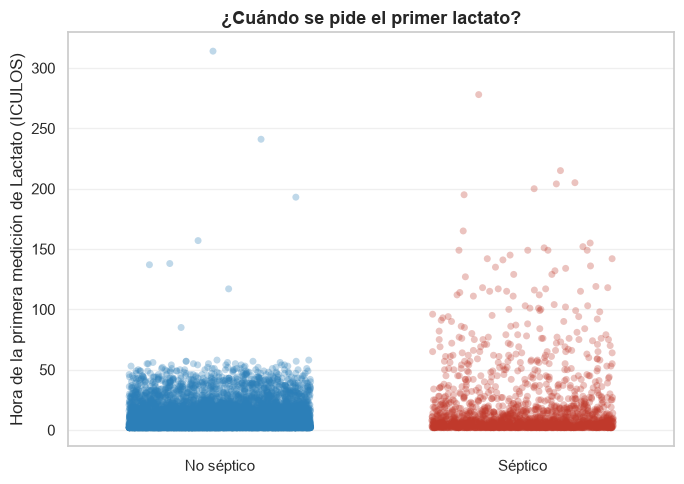

In [2]:
primer_lactato = (df.loc[df["Lactate"].notna()]
                   .groupby("pid", observed=True)
                   .agg(hora=("ICULOS", "min"), septico=("_septico_paciente", "first")))
primer_lactato["grupo"] = primer_lactato["septico"].map({0: "No séptico", 1: "Séptico"})

fig, ax = plt.subplots(figsize=(7, 5))
sns.stripplot(data=primer_lactato, x="grupo", y="hora", hue="grupo",
              palette={"No séptico": viz.COLOR_CONTROL, "Séptico": viz.COLOR_SEPSIS},
              alpha=0.3, jitter=0.3, legend=False, ax=ax)
ax.set_ylabel("Hora de la primera medición de Lactato (ICULOS)")
ax.set_xlabel("")
ax.set_title("¿Cuándo se pide el primer lactato?")
plt.tight_layout()

print(primer_lactato.groupby("grupo")["hora"].describe(percentiles=[.5]).round(1).to_string())
pacientes_por_grupo = (df.groupby("pid", observed=True)["_septico_paciente"].first()
                       .value_counts().rename({0: "No séptico", 1: "Séptico"}))
cobertura = primer_lactato.groupby("grupo").size() / pacientes_por_grupo
print("\n% de pacientes a los que alguna vez se les mide lactato:")
print((cobertura * 100).round(1).to_string())

La sorpresa es que **la mediana es casi igual** (6h en sépticos vs 5h en controles) — cuando
se pide, se pide temprano en ambos grupos, típicamente al ingreso. Lo que sí difiere, y mucho,
es la **cobertura**: a 62,0% de los sépticos se les mide lactato alguna vez en su estancia,
frente a solo 28,5% de los controles. Y la media (16,3h vs 9,0h) es mucho más alta que la
mediana en el grupo séptico — señal de una cola larga de mediciones repetidas más tarde en la
estancia. **Es el mismo patrón que ya vimos con la duración de la estancia en el notebook 01**:
la mediana casi no distingue a los grupos, pero la cola y la frecuencia sí. La lectura correcta
de "se pide más lactato a los sépticos" no es que se adelante el reloj, es que **se repite más
veces**.

## 2. La forma de la distribución de HR cambia con el tiempo de estancia

Un `ridge plot` (o *joyplot*): la distribución de `HR` completa, no solo su media, para cada
bloque de horas de estancia. Superponer las curvas de densidad deja ver si la población se
desplaza o si solo se ensancha.

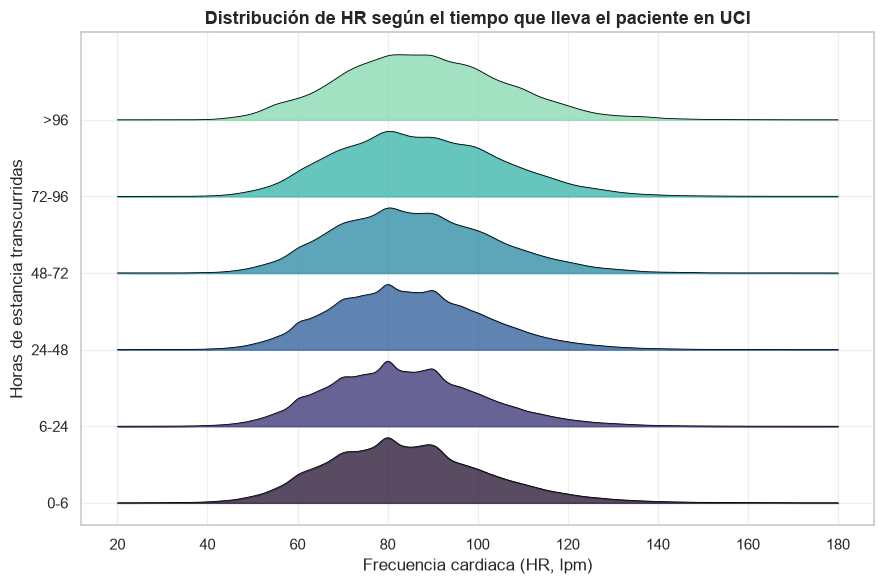

In [3]:
bins_ridge = [0, 6, 24, 48, 72, 96, np.inf]
etiquetas_ridge = ["0-6", "6-24", "24-48", "48-72", "72-96", ">96"]
df["_bloque_ridge"] = pd.cut(df["ICULOS"], bins=bins_ridge, labels=etiquetas_ridge, right=True)

colores_ridge = sns.color_palette("mako", n_colors=len(etiquetas_ridge))
x_grid = np.linspace(20, 180, 300)

fig, ax = plt.subplots(figsize=(9, 6))
for i, (bloque, color) in enumerate(zip(etiquetas_ridge, colores_ridge)):
    valores = df.loc[df["_bloque_ridge"] == bloque, "HR"].dropna()
    densidad = gaussian_kde(valores)(x_grid)
    densidad = densidad / densidad.max() * 0.85
    ax.fill_between(x_grid, densidad + i, i, color=color, alpha=0.8)
    ax.plot(x_grid, densidad + i, color="black", lw=0.6)

ax.set_yticks(range(len(etiquetas_ridge)))
ax.set_yticklabels(etiquetas_ridge)
ax.set_xlabel("Frecuencia cardiaca (HR, lpm)")
ax.set_ylabel("Horas de estancia transcurridas")
ax.set_title("Distribución de HR según el tiempo que lleva el paciente en UCI")
plt.tight_layout()

Hay un desplazamiento real hacia la derecha: la media de `HR` pasa de 84,0–84,8 lpm en las
primeras 48 horas a **87,9 lpm después de 96 horas**, casi 4 lpm más. No es solo que la
población de estancias largas tenga más varianza (`std` sube de 17,1 a 18,1, un cambio menor):
**se desplaza entera hacia frecuencias más altas**. Es coherente con una explicación de
composición, no de fisiología pura: los pacientes que siguen en UCI después de 4 días son, en
promedio, un subconjunto más comprometido — muchos de los que iban a mejorar rápido ya se
fueron.

## 3. Labs clave, alineados al evento: ¿hay tendencia, o es solo ruido?

Repetimos la lógica de trayectoria alineada del notebook 01, pero para cuatro laboratorios
que la literatura asocia con sepsis (`WBC`, `Creatinine`, `Platelets`, `BUN`), en paneles
separados para no saturar un solo gráfico.

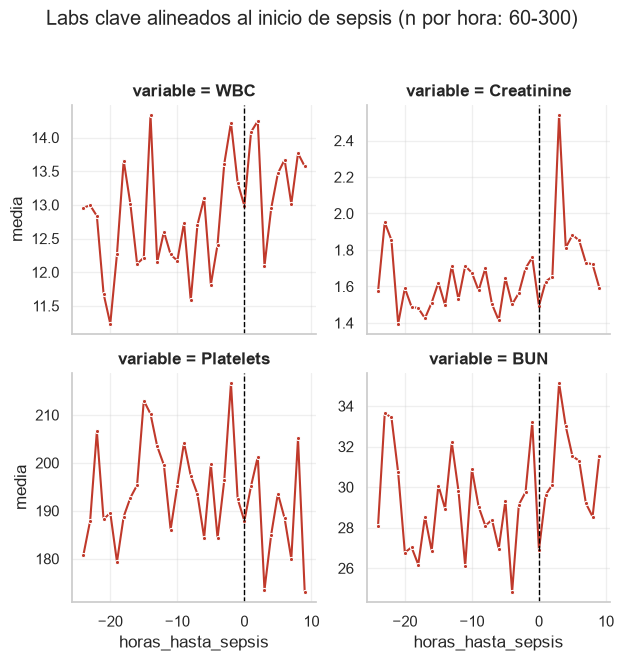

In [4]:
ventana = df[df["pid"].isin(onset.index) & df["horas_hasta_sepsis"].between(-24, 9)]

labs_facet = ["WBC", "Creatinine", "Platelets", "BUN"]
largo = (ventana.groupby("horas_hasta_sepsis")[labs_facet].mean()
         .reset_index().melt(id_vars="horas_hasta_sepsis", var_name="variable", value_name="media"))

g = sns.FacetGrid(largo, col="variable", col_wrap=2, height=3.2, sharey=False)
g.map_dataframe(sns.lineplot, x="horas_hasta_sepsis", y="media", color=viz.COLOR_SEPSIS, marker="o", markersize=3)
for ax in g.axes.flat:
    ax.axvline(0, color="black", ls="--", lw=1)
g.figure.suptitle("Labs clave alineados al inicio de sepsis (n por hora: 60-300)", y=1.03)
plt.tight_layout()

A diferencia de `HR`/`MAP` en el notebook 01, aquí **no hay una tendencia limpia**: las cuatro
líneas suben y bajan sin patrón monótono claro dentro de la ventana. La explicación no es que
estos labs sean irrelevantes clínicamente —lo son, y mucho— sino que el tamaño de muestra por
hora es demasiado pequeño (60–300 mediciones, frente a >2.000 de los vitales) para que el
promedio sea estable. Es una limitación honesta del análisis agregado, no un hallazgo
negativo sobre las variables: confirma por qué el notebook 05 va a preferir arrastrar el
último valor conocido con su antigüedad, en vez de promediar por hora una serie tan dispersa.

## 4. Lactato: la banda de variabilidad es más ancha que la propia tendencia

El lactato es el marcador más citado en sepsis. Repetimos su trayectoria, pero mostrando
**± 1 desviación estándar** (no el error estándar del notebook 01) para ver la variabilidad
real entre pacientes, no solo la incertidumbre del promedio.

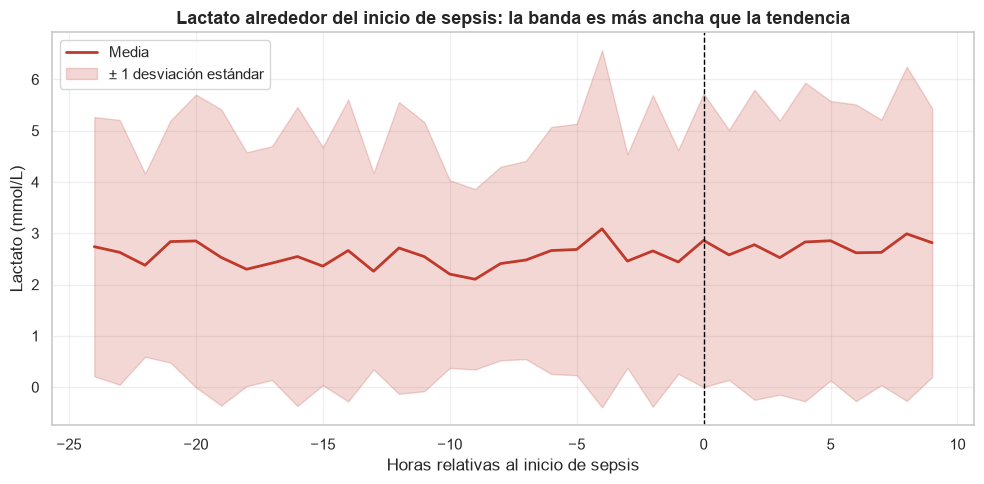

In [5]:
lactato_stats = ventana.groupby("horas_hasta_sepsis")["Lactate"].agg(["mean", "std"]).dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(lactato_stats.index, lactato_stats["mean"], color=viz.COLOR_SEPSIS, lw=2, label="Media")
ax.fill_between(lactato_stats.index,
                lactato_stats["mean"] - lactato_stats["std"],
                lactato_stats["mean"] + lactato_stats["std"],
                color=viz.COLOR_SEPSIS, alpha=0.2, label="± 1 desviación estándar")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Horas relativas al inicio de sepsis")
ax.set_ylabel("Lactato (mmol/L)")
ax.set_title("Lactato alrededor del inicio de sepsis: la banda es más ancha que la tendencia")
ax.legend()
plt.tight_layout()

La desviación estándar (1,8–3,5) es **del mismo orden que la propia media** (2,1–3,1) en casi
todas las horas: la banda sombreada es casi tan alta como la línea. Esto tiene una
consecuencia práctica directa, no solo estética: **el valor absoluto de lactato de un paciente
aislado no permite ubicarlo respecto al promedio con confianza** — la heterogeneidad entre
pacientes es demasiado grande. Confirma, con evidencia y no por intuición, que este proyecto
necesita features de tendencia *individual* (¿este lactato subió respecto al lactato anterior
del mismo paciente?) más que comparaciones contra la población.

## 5. Un paciente, sin promediar: la serie de tiempo real

Todo lo anterior son promedios de población. Volvemos al mismo paciente ejemplo del notebook
01 (`p011251`) para ver su serie de tiempo **sin alinear ni promediar** — la forma en que un
clínico lo vería al lado de la cama.

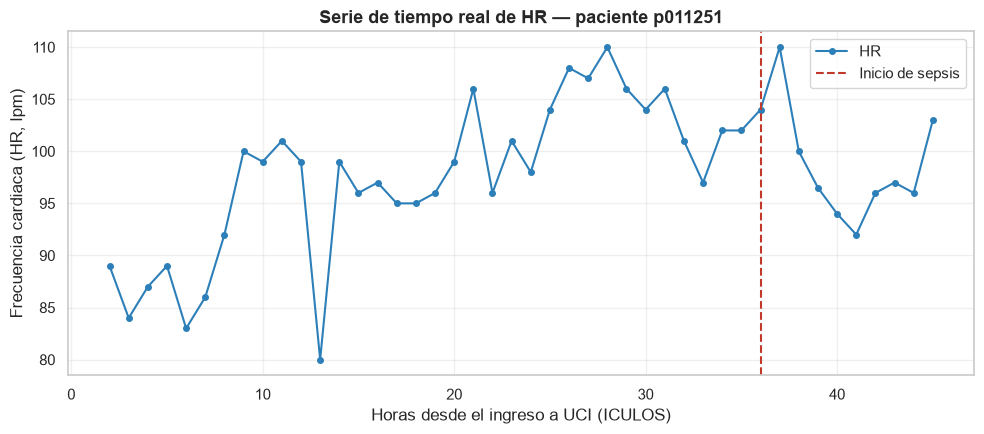

In [6]:
pe = df[df["pid"] == paciente_ejemplo].sort_values("ICULOS")
onset_pe = pe.loc[pe["SepsisLabel"] == 1, "ICULOS"].min()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(pe["ICULOS"], pe["HR"], marker="o", ms=4, color=viz.COLOR_CONTROL, label="HR")
ax.axvline(onset_pe, color=viz.COLOR_SEPSIS, ls="--", lw=1.5, label="Inicio de sepsis")
ax.set_xlabel("Horas desde el ingreso a UCI (ICULOS)")
ax.set_ylabel("Frecuencia cardiaca (HR, lpm)")
ax.set_title(f"Serie de tiempo real de HR — paciente {paciente_ejemplo}")
ax.legend()
plt.tight_layout()

A nivel individual se ven huecos (horas sin medición) y fluctuaciones bruscas que el promedio
poblacional del notebook 01 diluye por completo. Es exactamente el tipo de gráfico que
justifica por qué "el valor de esta hora" es una mala unidad de análisis por sí sola: hay que
mirar la trayectoria completa del paciente, no el punto aislado.

## 6. Perfil multivariante: ¿los sépticos "se ven" distintos en conjunto?

Hasta ahora miramos variables de a una. Un gráfico de **coordenadas paralelas** resume el
perfil promedio de cada paciente en varias variables a la vez (cada una normalizada a 0–1
para poder compararlas en el mismo eje) y traza una línea por paciente.

In [7]:
perfil_vars = ["HR", "Resp", "MAP", "WBC", "Lactate"]
perfil = df.groupby("pid", observed=True)[perfil_vars].mean()  # media por columna, ignora NaN de esa columna
perfil["shock_index"] = (df["HR"] / df["SBP"].replace(0, np.nan)).groupby(df["pid"], observed=True).mean()
perfil["grupo"] = df.groupby("pid", observed=True)["_septico_paciente"].first().map({0: "No séptico", 1: "Séptico"})

# Tabla de referencia: promedio real por variable, sobre TODOS los pacientes que la tienen
# medida alguna vez (sin exigir que tengan las 6 a la vez todavía).
tabla_perfil = perfil.groupby("grupo")[perfil_vars + ["shock_index"]].mean().round(3)
tabla_perfil

,HR,Resp,MAP,WBC,Lactate,shock_index
grupo,,,,,,
No séptico,83.389999,18.445999,82.695000,10.939,2.154,0.700
Séptico,89.098999,19.643000,80.504997,12.785,2.211,0.764


`HR` (89,1 vs 83,4), `Resp` (19,6 vs 18,4) y `shock_index` (0,764 vs 0,700) son más altos en
sépticos; `MAP` es más bajo (80,5 vs 82,7) — el patrón de shock séptico, ahora cuantificado
variable por variable. `Lactate`, en cambio, es casi idéntico entre grupos (2,21 vs 2,15): no
contradice el hallazgo del notebook 02 —sigue siendo cierto que se *pide* mucho más a los
sépticos— pero confirma lo que vimos en la Sección 4: cuando sí se mide, su valor promedio por
sí solo no separa tan bien como su sola presencia o su tendencia dentro del mismo paciente.

Para dibujar las coordenadas paralelas hace falta algo más estricto que el promedio por
columna: cada línea tiene que atravesar los 6 ejes, así que solo entran pacientes con **las 6
variables medidas al menos una vez** — y como el `Lactate` de la Sección 1 solo cubre a una
minoría, ese filtro va a dejar una submuestra sesgada hacia los pacientes más monitoreados.
Lo mostramos así, con el sesgo declarado, en vez de disimularlo:

Pacientes con las 6 variables medidas alguna vez: 12,183 de 40,336 (30.2%) — la submuestra del gráfico, no la cohorte completa.


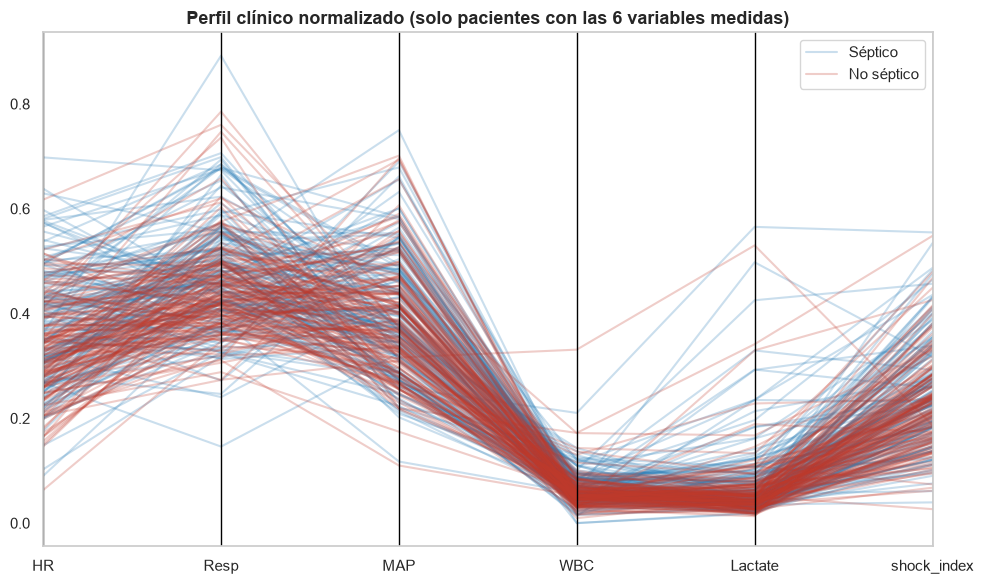

In [8]:
perfil_completo = perfil.dropna()
print(f"Pacientes con las 6 variables medidas alguna vez: {len(perfil_completo):,} de {len(perfil):,} "
      f"({len(perfil_completo) / len(perfil) * 100:.1f}%) — la submuestra del gráfico, no la cohorte completa.")

escalado = perfil_completo.copy()
escalado[perfil_vars + ["shock_index"]] = MinMaxScaler().fit_transform(perfil_completo[perfil_vars + ["shock_index"]])

n_septicos_completo = (escalado.grupo == "Séptico").sum()
muestra = pd.concat([
    escalado[escalado.grupo == "Séptico"].sample(min(150, n_septicos_completo), random_state=1),
    escalado[escalado.grupo == "No séptico"].sample(150, random_state=1),
])

fig, ax = plt.subplots(figsize=(10, 6))
parallel_coordinates(muestra, "grupo", color=[viz.COLOR_CONTROL, viz.COLOR_SEPSIS], alpha=0.25, ax=ax)
ax.set_title("Perfil clínico normalizado (solo pacientes con las 6 variables medidas)")
ax.legend(loc="upper right")
plt.tight_layout()

Esta submuestra —más monitoreada que la cohorte general, por construcción— sigue mostrando el
mismo patrón cualitativo (sépticos más arriba en `HR`/`Resp`/`shock_index`, más abajo en
`MAP`), lo que da algo de confianza en que el patrón no es un artefacto del filtro. Pero el
número exacto de cada línea individual en este gráfico no debe leerse como representativo de
toda la cohorte — para eso está la tabla de la celda anterior, calculada sin ese sesgo.

## 7. Espagueti: la heterogeneidad detrás del promedio del notebook 01

Volvemos a la trayectoria alineada de `HR`, pero en vez de solo la media, dibujamos una línea
fina por cada paciente de una muestra, con la media superpuesta en trazo grueso. El notebook
01 mostró que la media sube de forma modesta (+2,8 lpm en 30h) — aquí vemos si esa subida es
un patrón compartido por todos o el promedio de trayectorias muy distintas entre sí.

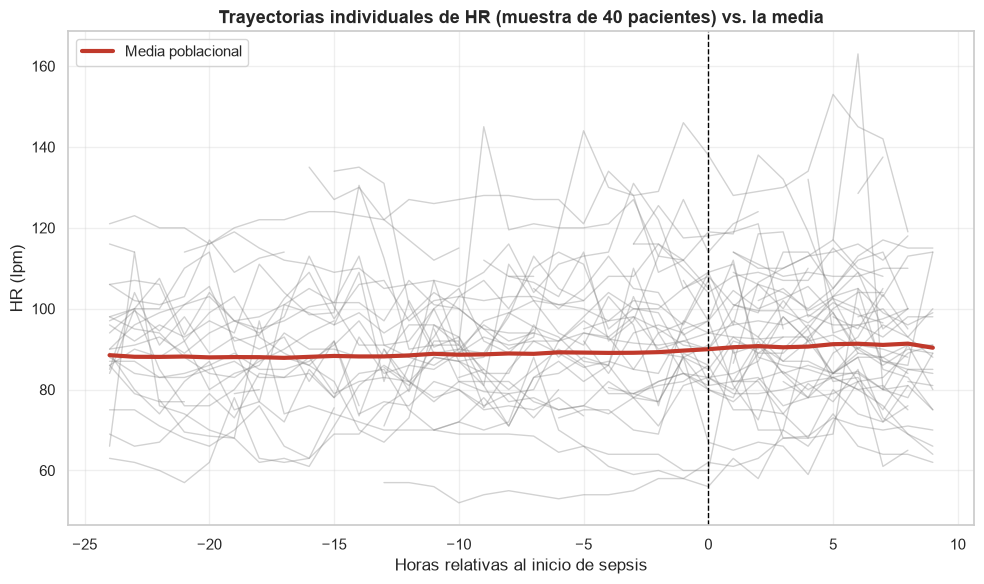

In [9]:
muestra_pids_spaghetti = ventana["pid"].drop_duplicates().sample(40, random_state=42)
espagueti = ventana[ventana["pid"].isin(muestra_pids_spaghetti)]

fig, ax = plt.subplots(figsize=(10, 6))
for pid, g in espagueti.groupby("pid", observed=True):
    ax.plot(g["horas_hasta_sepsis"], g["HR"], color="grey", alpha=0.35, lw=1)

tendencia = ventana.groupby("horas_hasta_sepsis")["HR"].mean()
ax.plot(tendencia.index, tendencia.values, color=viz.COLOR_SEPSIS, lw=3, label="Media poblacional")
ax.axvline(0, color="black", ls="--", lw=1)
ax.set_xlabel("Horas relativas al inicio de sepsis")
ax.set_ylabel("HR (lpm)")
ax.set_title("Trayectorias individuales de HR (muestra de 40 pacientes) vs. la media")
ax.legend()
plt.tight_layout()

La nube gris confirma la sospecha: hay pacientes que suben mucho, otros que bajan, y otros
prácticamente planos — **no todos los sépticos "avisan" con taquicardia**. La línea roja de
+2,8 lpm en 30 horas es un promedio real, pero esconde una heterogeneidad clínica considerable.
Esto tiene una consecuencia directa para el modelado del notebook 06: un modelo que solo
aprenda "la tendencia promedio" va a fallar en el subconjunto de pacientes cuya alerta viene
por otra vía (respiración, presión, laboratorios) y no por la frecuencia cardiaca — un
argumento más a favor de dejar que el modelo combine muchas señales, no solo una.

## 8. ¿En qué momento de la estancia se concentra la petición de lactato?

Volviendo a jugar con el reloj de la estancia (no el del evento): un `rug plot` marca, con una
rayita, cada medición individual de lactato en su hora exacta, superpuesto a la curva de
densidad — para ver si las peticiones se agrupan en algún tramo.

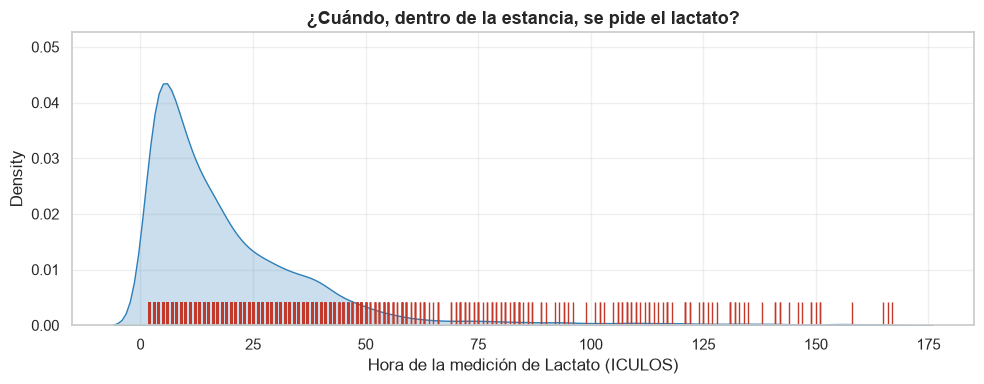

In [10]:
horas_lactato = df.loc[df["Lactate"].notna(), "ICULOS"]
horas_lactato_168 = horas_lactato[horas_lactato <= 168]
muestra_rug = horas_lactato_168.sample(min(len(horas_lactato_168), 3000), random_state=42)

fig, ax = plt.subplots(figsize=(10, 4))
sns.kdeplot(horas_lactato_168, color=viz.COLOR_CONTROL, fill=True, alpha=0.25, ax=ax)
sns.rugplot(muestra_rug, color=viz.COLOR_SEPSIS, height=0.08, ax=ax)
ax.set_xlabel("Hora de la medición de Lactato (ICULOS)")
ax.set_title("¿Cuándo, dentro de la estancia, se pide el lactato?")
plt.tight_layout()

La densidad se concentra con claridad en las **primeras 24 horas** y decae después — coherente
con la Sección 1: el lactato es sobre todo un examen de **evaluación inicial**, no de
seguimiento continuo. Esto también explica por qué el notebook 05 necesita una feature de
"antigüedad del último valor" (`Lactate_edad`): pasadas las primeras horas, la mayoría de los
pacientes está viviendo con un lactato cada vez más viejo, no con uno actualizado.

## 9. Línea de tiempo clínica: el inicio de sepsis no tiene un momento fijo

Cerramos con una vista tipo Gantt: para una muestra de pacientes sépticos, una barra
horizontal marca la duración total de su estancia, y un rombo marca la hora exacta en que se
declaró la sepsis. Es la forma más directa de ver, paciente por paciente, algo que el
notebook 01 ya mostró de forma agregada (Sección 4.2): que el evento no ocurre en un momento
predecible de la estancia.

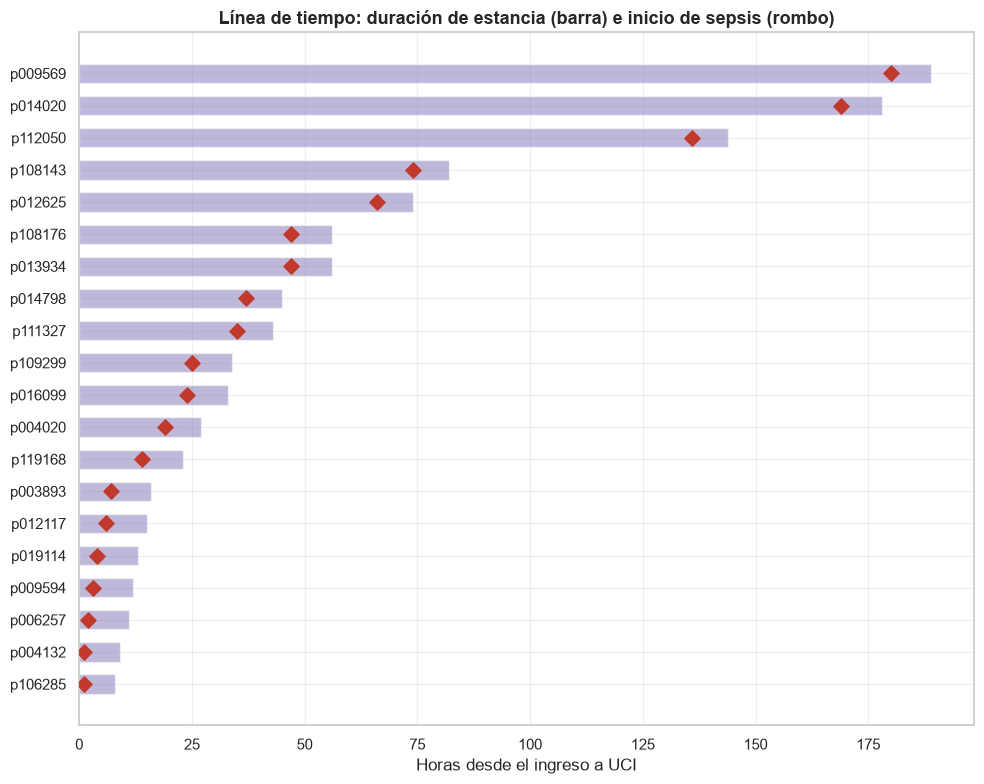

In [11]:
muestra_timeline = onset.sample(20, random_state=11).sort_values()
duracion = df[df["pid"].isin(muestra_timeline.index)].groupby("pid", observed=True)["ICULOS"].max()

fig, ax = plt.subplots(figsize=(10, 8))
for i, pid in enumerate(muestra_timeline.index):
    ax.barh(i, duracion[pid], left=0, color="#8172B2", alpha=0.5, height=0.6)
    ax.scatter(muestra_timeline[pid], i, color=viz.COLOR_SEPSIS, zorder=5, marker="D", s=60)

ax.set_yticks(range(len(muestra_timeline)))
ax.set_yticklabels(muestra_timeline.index)
ax.set_xlabel("Horas desde el ingreso a UCI")
ax.set_title("Línea de tiempo: duración de estancia (barra) e inicio de sepsis (rombo)")
plt.tight_layout()

El rombo cae en cualquier punto de la barra —a veces casi al inicio, a veces cerca del final—
sin ningún patrón visual consistente. Confirma, ahora paciente por paciente y no solo en un
histograma agregado, que el problema **no admite un atajo de "predecir una vez al ingreso"**:
tiene que resolverse hora a hora, como está planteado desde el diseño original del challenge.

## 10. Qué sabemos al cerrar este notebook

- **La mediana vuelve a engañar**: igual que con la duración de estancia (notebook 01), la
  hora en que se pide el primer lactato es casi igual entre grupos — lo que distingue a los
  sépticos es la *cobertura* (62% vs 28,5%) y la repetición, no la rapidez del primer examen.
- **La población de estancias largas es distinta, no solo más variable**: la distribución de
  `HR` se desplaza entera hacia valores más altos con el tiempo de estancia (+4 lpm después de
  96h), consistente con que los casos que persisten en UCI son, en promedio, más comprometidos.
- **Los labs raros no muestran tendencia limpia alineados al evento** (WBC, Creatinine,
  Platelets, BUN): el tamaño de muestra por hora es demasiado chico. No es que no importen —
  es que el promedio agregado no es la forma correcta de mirarlos.
- **La variabilidad entre pacientes en Lactato es tan grande como su propia tendencia**: la
  banda de ±1 desviación estándar es casi tan alta como la media. Refuerza la necesidad de
  features de tendencia individual, no de comparación contra la población.
- **Detrás del promedio hay heterogeneidad real**: el espagueti de HR muestra que no todos los
  sépticos "avisan" igual — algunos suben, otros no. Un modelo robusto necesita combinar señales.
- **El lactato se concentra en las primeras 24h de estancia**: apoya incluir `_edad` (antigüedad
  del último valor) como feature, no solo el valor arrastrado.
- **El inicio de sepsis no tiene un momento fijo**, ni agregado (notebook 01) ni paciente por
  paciente (aquí): el problema debe resolverse hora a hora.
